In [1]:
#Loading Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("appleAppData.csv")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (1230376, 21)

Columns: ['App_Id', 'App_Name', 'AppStore_Url', 'Primary_Genre', 'Content_Rating', 'Size_Bytes', 'Required_IOS_Version', 'Released', 'Updated', 'Version', 'Price', 'Currency', 'Free', 'DeveloperId', 'Developer', 'Developer_Url', 'Developer_Website', 'Average_User_Rating', 'Reviews', 'Current_Version_Score', 'Current_Version_Reviews']


,App_Id,App_Name,AppStore_Url,Primary_Genre,Content_Rating,Size_Bytes,Required_IOS_Version,Released,Updated,Version,...,Currency,Free,DeveloperId,Developer,Developer_Url,Developer_Website,Average_User_Rating,Reviews,Current_Version_Score,Current_Version_Reviews
0,com.hkbu.arc.apaper,A+ Paper Guide,https://apps.apple.com/us/app/a-paper-guide/id...,Education,4+,21993472.0,8.0,2017-09-28T03:02:41Z,2018-12-21T21:30:36Z,1.1.2,...,USD,True,1375410542,HKBU ARC,https://apps.apple.com/us/developer/hkbu-arc/i...,NaN,0.0,0,0.0,0
1,com.dmitriev.abooks,A-Books,https://apps.apple.com/us/app/a-books/id103157...,Book,4+,13135872.0,10.0,2015-08-31T19:31:32Z,2019-07-23T20:31:09Z,1.3,...,USD,True,1031572001,Roman Dmitriev,https://apps.apple.com/us/developer/roman-dmit...,NaN,5.0,1,5.0,1
2,no.terp.abooks,A-books,https://apps.apple.com/us/app/a-books/id145702...,Book,4+,21943296.0,9.0,2021-04-14T07:00:00Z,2021-05-30T21:08:54Z,1.3.1,...,USD,True,1457024163,Terp AS,https://apps.apple.com/us/developer/terp-as/id...,NaN,0.0,0,0.0,0
3,fr.antoinettefleur.Book1,A-F Book #1,https://apps.apple.com/us/app/a-f-book-1/id500...,Book,4+,81851392.0,8.0,2012-02-10T03:40:07Z,2019-10-29T12:40:37Z,1.2,...,USD,False,439568839,i-editeur.com,https://apps.apple.com/us/developer/i-editeur-...,NaN,0.0,0,0.0,0
4,com.imonstersoft.azdictionaryios,A-Z Synonyms Dictionary,https://apps.apple.com/us/app/a-z-synonyms-dic...,Reference,4+,64692224.0,9.0,2020-12-16T08:00:00Z,2020-12-18T21:36:11Z,1.0.1,...,USD,True,656731821,Ngov chiheang,https://apps.apple.com/us/developer/ngov-chihe...,http://imonstersoft.com,0.0,0,0.0,0


In [5]:
#Check data types & missing values
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

App_Id                         str
App_Name                       str
AppStore_Url                   str
Primary_Genre                  str
Content_Rating                 str
Size_Bytes                 float64
Required_IOS_Version           str
Released                       str
Updated                        str
Version                        str
Price                      float64
Currency                       str
Free                          bool
DeveloperId                  int64
Developer                      str
Developer_Url                  str
Developer_Website              str
Average_User_Rating        float64
Reviews                      int64
Current_Version_Score      float64
Current_Version_Reviews      int64
dtype: object

Missing values:
App_Id                          0
App_Name                        1
AppStore_Url                    0
Primary_Genre                   0
Content_Rating                  0
Size_Bytes                    224
Required_IOS_Version          

In [6]:
# Data cleaning
df['Released'] = pd.to_datetime(df['Released'], errors='coerce')
df['Updated'] = pd.to_datetime(df['Updated'], errors='coerce')
df['Size_MB'] = df['Size_Bytes'] / (1024 * 1024)
df = df[df['Reviews'] >= 10]
df = df.dropna(subset=['Average_User_Rating'])
df = df.drop_duplicates(subset=['App_Name', 'Primary_Genre'])
print("Shape after cleaning:", df.shape)

Shape after cleaning: (184544, 22)


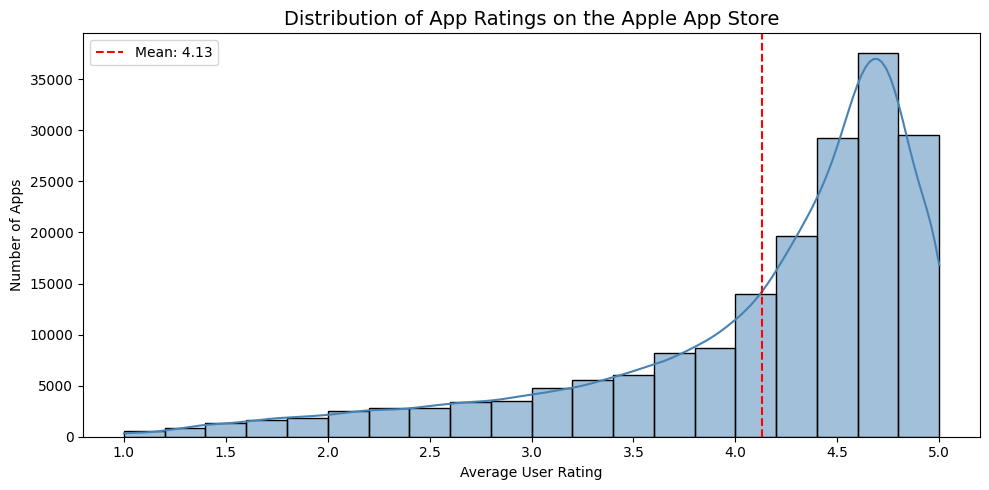

count    184544.000000
mean          4.130118
std           0.835603
min           1.000000
25%           3.812500
50%           4.431130
75%           4.713570
max           5.000000
Name: Average_User_Rating, dtype: float64


In [7]:
#Rating distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Average_User_Rating'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of App Ratings on the Apple App Store', fontsize=14)
plt.xlabel('Average User Rating')
plt.ylabel('Number of Apps')
plt.axvline(df['Average_User_Rating'].mean(), color='red', linestyle='--', label=f"Mean: {df['Average_User_Rating'].mean():.2f}")
plt.legend()
plt.tight_layout()
plt.show()
print(df['Average_User_Rating'].describe())

/var/folders/lr/6lfxt4wx2kb6nch_7vwx8y7r0000gn/T/ipykernel_74775/1509850796.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_ratings.values, y=category_ratings.index, palette='Blues_r')


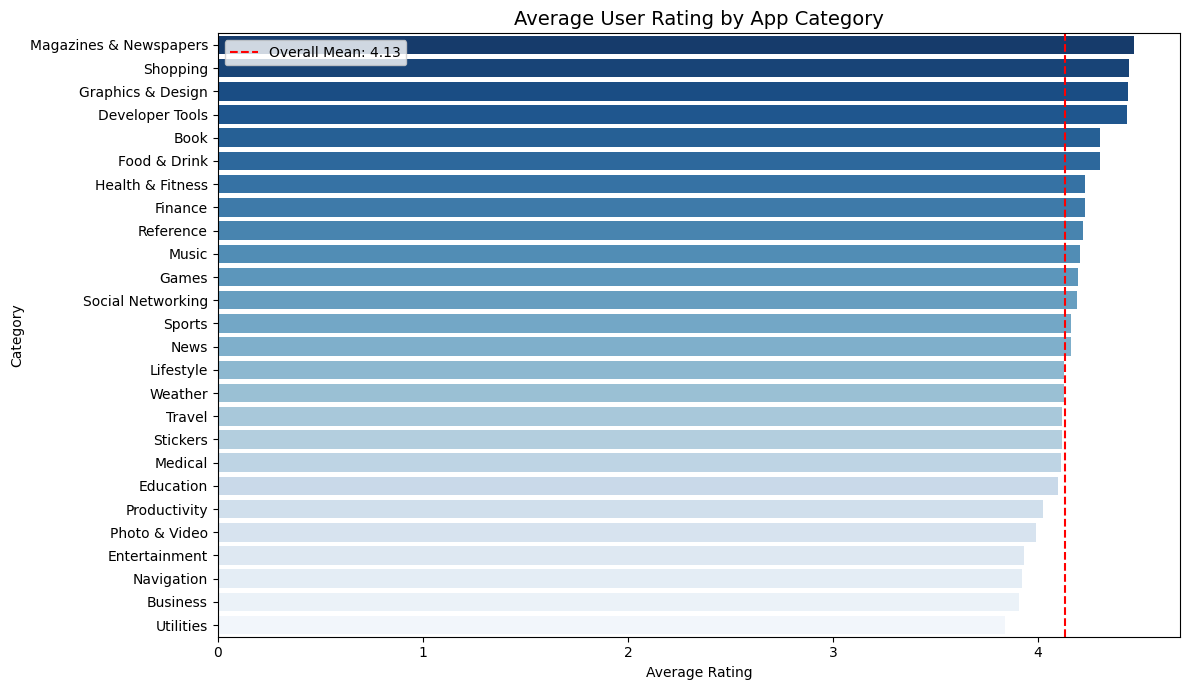

In [8]:
# Rating by category
category_ratings = df.groupby('Primary_Genre')['Average_User_Rating'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 7))
sns.barplot(x=category_ratings.values, y=category_ratings.index, palette='Blues_r')
plt.title('Average User Rating by App Category', fontsize=14)
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.axvline(df['Average_User_Rating'].mean(), color='red', linestyle='--', label=f"Overall Mean: {df['Average_User_Rating'].mean():.2f}")
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/lr/6lfxt4wx2kb6nch_7vwx8y7r0000gn/T/ipykernel_74775/3802609074.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Free', y='Average_User_Rating', data=df, palette={'True': 'steelblue', 'False': 'coral'})


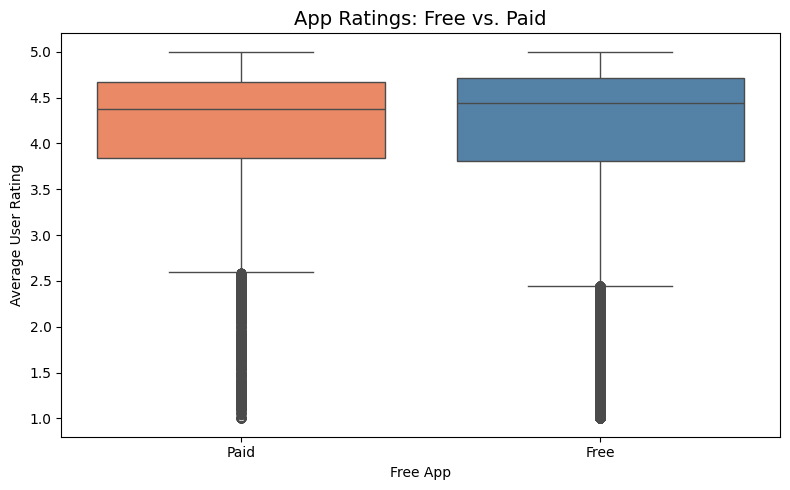

          count      mean       std  min       25%     50%       75%  max
Free                                                                     
False   16794.0  4.128411  0.781030  1.0  3.837368  4.3750  4.667150  5.0
True   167750.0  4.130289  0.840874  1.0  3.808220  4.4375  4.716778  5.0


In [9]:
#Free vs Paid
plt.figure(figsize=(8, 5))
sns.boxplot(x='Free', y='Average_User_Rating', data=df, palette={'True': 'steelblue', 'False': 'coral'})
plt.title('App Ratings: Free vs. Paid', fontsize=14)
plt.xlabel('Free App')
plt.ylabel('Average User Rating')
plt.xticks([0, 1], ['Paid', 'Free'])
plt.tight_layout()
plt.show()
print(df.groupby('Free')['Average_User_Rating'].describe())

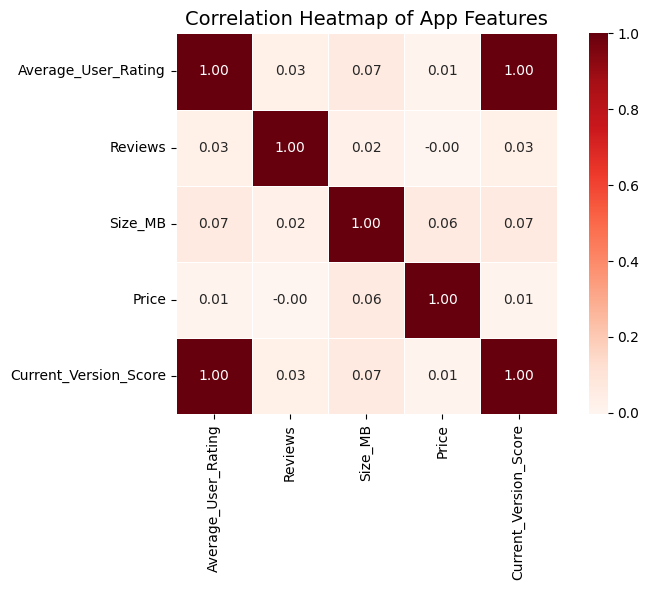

In [10]:
#Correlation heatmap
numeric_cols = ['Average_User_Rating', 'Reviews', 'Size_MB', 'Price', 'Current_Version_Score']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='Reds', square=True, linewidths=0.5)
plt.title('Correlation Heatmap of App Features', fontsize=14)
plt.tight_layout()
plt.show()

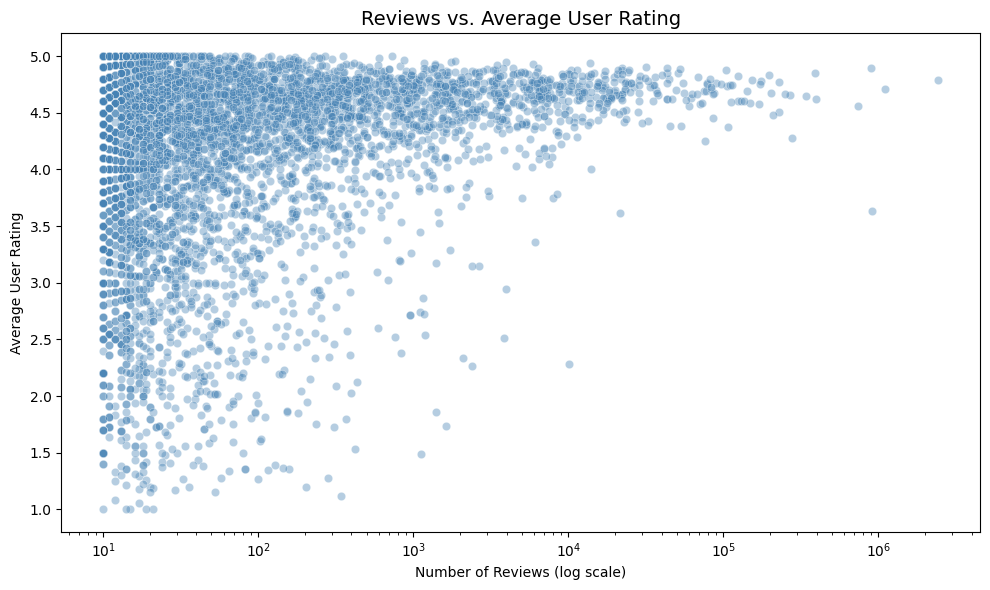

In [11]:
#Reviews vs Rating
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Reviews', y='Average_User_Rating', data=df.sample(5000), alpha=0.4, color='steelblue')
plt.xscale('log')
plt.title('Reviews vs. Average User Rating', fontsize=14)
plt.xlabel('Number of Reviews (log scale)')
plt.ylabel('Average User Rating')
plt.tight_layout()
plt.show()